Connected to hyriver-dev (Python 3.12.5)

<>:101: SyntaxWarning: invalid escape sequence '\g'
<>:101: SyntaxWarning: invalid escape sequence '\g'
<ipython-input-1-bb7722180c54>:101: SyntaxWarning: invalid escape sequence '\g'
  f"FBUY Pass Rate ($\ge$ FBUY-5): {fbuy_pass_rate:.1f}%\n"


1) Loading Master Spatiotemporal Matrix...
2) Aggregating Statewide Totals...
3) Calculating Statistics...
4) Running FBUY Assessment...
5) Generating Visualizations...
Statewide Statistical Agreement
-------------------------------
$R^2$ (Temporal Match): 0.515
Mean Error (Bias): 3,585 units/5-yrs
FBUY Pass Rate ($\ge$ FBUY-5): 84.2%
Total LED Analyzed: 2,821,459


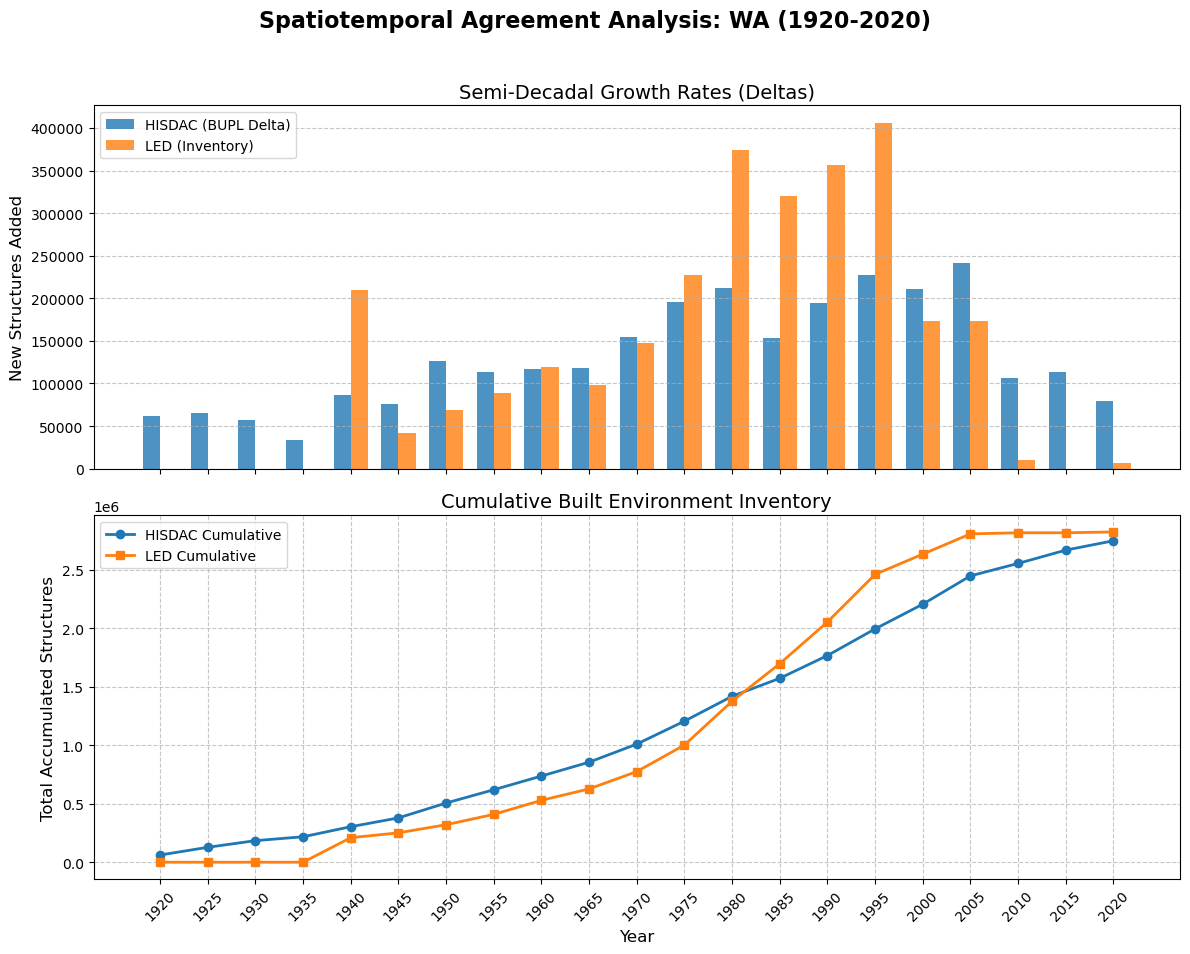


--- FBUY Anchor Assessment ---
Total Buildings in Valid HISDAC Pixels: 2,821,459
Buildings Passing the FBUY Test: 2,374,302
Pass Rate: 84.15%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Setup Paths ---
DATA_PATH = Path("/Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data")
TESTING_SET_PATH = DATA_PATH / "Testing_Set"
state_code = "WA"  # Ensure this matches your previous runs

print("1) Loading Master Spatiotemporal Matrix...")
master_matrix_path = TESTING_SET_PATH / f"{state_code}_Master_Spatiotemporal_Matrix.parquet"
master_df = pd.read_parquet(master_matrix_path)

# Define our expected years
years = list(range(1920, 2025, 5))
hisdac_cols = [f"D_BUPL{y}" for y in years]
led_cols = [f"LED_{y}" for y in years]

# --- 1. Calculate Statewide Time Series (Deltas & Cumulative) ---
print("2) Aggregating Statewide Totals...")
hisdac_deltas = master_df[hisdac_cols].sum().values
led_deltas = master_df[led_cols].sum().values

# Calculate cumulative totals
hisdac_cumulative = np.cumsum(hisdac_deltas)
led_cumulative = np.cumsum(led_deltas)

# --- 2. Calculate Correlation and Error Metrics ---
# We calculate metrics on the Delta curves (the actual growth rates)
print("3) Calculating Statistics...")
# Mean Error (Bias): Negative means LED undercounts compared to HISDAC, Positive means LED overcounts
mean_error = np.mean(led_deltas - hisdac_deltas)

# R^2 (Coefficient of Determination) comparing the two temporal distributions
ss_res = np.sum((led_deltas - hisdac_deltas)**2)
ss_tot = np.sum((led_deltas - np.mean(led_deltas))**2)
r_squared = 1 - (ss_res / ss_tot)

# --- 3. Calculate FBUY Agreement (% of buildings passing) ---
# For every pixel, find the FIRST year an LED building is recorded
print("4) Running FBUY Assessment...")
led_presence = master_df[led_cols] > 0
year_array = np.array(years)

# Create a mask where LED buildings exist, otherwise assign 9999 to find the minimum year
first_led_year_per_pixel = np.where(led_presence, year_array, 9999).min(axis=1)

# Isolate pixels that actually have an FBUY value (ignore NaNs where HISDAC is completely blank)
valid_fbuy_mask = master_df['FBUY'].notna() & (first_led_year_per_pixel != 9999)

# A pixel passes if its first LED building was built AFTER (or within 5 years before) the FBUY
# Using -5 as our agreed grace period for construction/tax lag
fbuy_values = master_df.loc[valid_fbuy_mask, 'FBUY']
led_first_years = first_led_year_per_pixel[valid_fbuy_mask]

passed_fbuy_mask = led_first_years >= (fbuy_values - 5)

# Calculate percentage weighted by the actual number of buildings in those pixels
total_led_per_pixel = master_df[led_cols].sum(axis=1)

# Total buildings in pixels that have a valid HISDAC FBUY
valid_buildings_total = total_led_per_pixel[valid_fbuy_mask].sum()
# Total buildings in pixels that PASSED the test
passed_buildings_total = total_led_per_pixel[valid_fbuy_mask][passed_fbuy_mask].sum()

fbuy_pass_rate = (passed_buildings_total / valid_buildings_total) * 100 if valid_buildings_total > 0 else 0

# --- 4. Plotting the Results ---
print("5) Generating Visualizations...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f"Spatiotemporal Agreement Analysis: {state_code} (1920-2020)", fontsize=16, fontweight='bold')

# Subplot 1: The Deltas (New Construction per 5-year interval)
width = 1.8 # Bar width
ax1.bar(np.array(years) - width/2, hisdac_deltas, width=width, label='HISDAC (BUPL Delta)', color='#1f77b4', alpha=0.8)
ax1.bar(np.array(years) + width/2, led_deltas, width=width, label='LED (Inventory)', color='#ff7f0e', alpha=0.8)

ax1.set_ylabel('New Structures Added', fontsize=12)
ax1.set_title('Semi-Decadal Growth Rates (Deltas)', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Cumulative Growth
ax2.plot(years, hisdac_cumulative, marker='o', linewidth=2, label='HISDAC Cumulative', color='#1f77b4')
ax2.plot(years, led_cumulative, marker='s', linewidth=2, label='LED Cumulative', color='#ff7f0e')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Total Accumulated Structures', fontsize=12)
ax2.set_title('Cumulative Built Environment Inventory', fontsize=14)
ax2.legend(loc='upper left')
ax2.grid(axis='both', linestyle='--', alpha=0.7)

# Add a Statistical Summary Text Box to the Cumulative Plot
stats_text = print((
    f"Statewide Statistical Agreement\n"
    f"-------------------------------\n"
    f"$R^2$ (Temporal Match): {r_squared:.3f}\n"
    f"Mean Error (Bias): {mean_error:,.0f} units/5-yrs\n"
    f"FBUY Pass Rate ($\ge$ FBUY-5): {fbuy_pass_rate:.1f}%\n"
    f"Total LED Analyzed: {master_df[led_cols].sum().sum():,.0f}"
))

# Place text box in lower right
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax2.text(0.97, 0.05, stats_text, transform=ax2.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

# Layout adjustments
plt.xticks(years, rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust for main title
plt.show()

# Optional: Print out the specific FBUY breakdown
print(f"\n--- FBUY Anchor Assessment ---")
print(f"Total Buildings in Valid HISDAC Pixels: {valid_buildings_total:,.0f}")
print(f"Buildings Passing the FBUY Test: {passed_buildings_total:,.0f}")
print(f"Pass Rate: {fbuy_pass_rate:.2f}%")

In [ ]:
print("1) Applying Corrected High-Confidence Filters...")

# Setup arrays
years = list(range(1920, 2025, 5))
year_array = np.array(years)
led_presence = master_df[led_cols] > 0
first_led_year_per_pixel = np.where(led_presence, year_array, 9999).min(axis=1)
total_led_per_pixel = master_df[led_cols].sum(axis=1)

# --- THE TEMPORAL MASK ---
# Path A: HISDAC exists, and the LED passes the anchor test
passes_fbuy = (
    master_df['FBUY'].notna() & 
    (first_led_year_per_pixel != 9999) & 
    (first_led_year_per_pixel >= (master_df['FBUY'] - 5))
)

# Path B: HISDAC is completely missing, but LED confirms buildings exist
# (These are the critical gaps your inventory fills)
missing_hisdac_but_has_led = master_df['FBUY'].isna() & (total_led_per_pixel > 0)

# Combine the temporal paths
temporal_confidence_mask = passes_fbuy | missing_hisdac_but_has_led

# --- THE DENSITY MASK ---
# Density must be <= 3.0 to drop high-rises. 
# If density is NaN (because HISDAC is missing), we keep it.
DENSITY_THRESHOLD = 3.0
density_mask = master_df['DENSITY'].isna() | (master_df['DENSITY'] <= DENSITY_THRESHOLD)

# --- THE FINAL MASK ---
high_confidence_mask = temporal_confidence_mask & density_mask
high_conf_df = master_df[high_confidence_mask]

# --- Recalculate Stats ---
print("2) Recalculating Metrics on Corrected Set...")

hc_hisdac_deltas = high_conf_df[hisdac_cols].sum().values
hc_led_deltas = high_conf_df[led_cols].sum().values

hc_mean_error = np.mean(hc_led_deltas - hc_hisdac_deltas)

hc_ss_res = np.sum((hc_led_deltas - hc_hisdac_deltas)**2)
hc_ss_tot = np.sum((hc_led_deltas - np.mean(hc_led_deltas))**2)
hc_r_squared = 1 - (hc_ss_res / hc_ss_tot)

buildings_retained = high_conf_df[led_cols].sum().sum()
original_total = master_df[led_cols].sum().sum()
retention_rate = (buildings_retained / original_total) * 100

print("\n=== CORRECTED HIGH-CONFIDENCE DASHBOARD ===")
print(f"High-Confidence R^2:   {hc_r_squared:.3f}")
print(f"High-Conf Mean Error:  {hc_mean_error:,.0f} units/5-yrs")
print(f"Total Buildings Retained: {buildings_retained:,.0f} ({retention_rate:.1f}% of total)")
print(f"Total Pixels Retained:    {len(high_conf_df):,.0f} pixels")
print("===========================================")

# Save the matrix
high_conf_out_path = TESTING_SET_PATH / f"{state_code}_High_Confidence_Matrix.parquet"
high_conf_df.to_parquet(high_conf_out_path, index=False)

1) Applying Corrected High-Confidence Filters...
2) Recalculating Metrics on Corrected Set...

=== CORRECTED HIGH-CONFIDENCE DASHBOARD ===
High-Confidence R^2:   0.549
High-Conf Mean Error:  2,974 units/5-yrs
Total Buildings Retained: 2,193,061 (77.7% of total)
Total Pixels Retained:    170,914 pixels
